In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = f'https://drive.usercontent.google.com/uc?id=1aQKKyZUJgusq9i80lNQgQJY2iE5fKqJo&authuser=0&export=download'

facebook_ads_data = pd.read_csv(url)
facebook_ads_data.head()

,ad_date,campaign_name,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
0,2022-11-05,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
1,2022-11-01,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
2,2022-10-31,Expansion,227.45,6054,58,191.87,3.92,37.57,0.009580,0.843570
3,2022-10-30,Expansion,335.91,27562,69,472.61,4.87,12.19,0.002503,1.406954
4,2022-10-29,Expansion,714.03,33358,115,680.34,6.21,21.41,0.003447,0.952817


In [23]:
facebook_ads_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1494 entries, 0 to 1493
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ad_date            1494 non-null   object 
 1   campaign_name      1494 non-null   object 
 2   total_spend        1494 non-null   float64
 3   total_impressions  1494 non-null   int64  
 4   total_clicks       1494 non-null   int64  
 5   total_value        1494 non-null   float64
 6   cpc                1443 non-null   float64
 7   cpm                1462 non-null   float64
 8   ctr                1462 non-null   float64
 9   romi               1462 non-null   float64
dtypes: float64(6), int64(2), object(2)
memory usage: 116.8+ KB


In [24]:
facebook_ads_data['ad_date'] = pd.to_datetime(facebook_ads_data['ad_date'])
facebook_ads_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1494 entries, 0 to 1493
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   ad_date            1494 non-null   datetime64[ns]
 1   campaign_name      1494 non-null   object        
 2   total_spend        1494 non-null   float64       
 3   total_impressions  1494 non-null   int64         
 4   total_clicks       1494 non-null   int64         
 5   total_value        1494 non-null   float64       
 6   cpc                1443 non-null   float64       
 7   cpm                1462 non-null   float64       
 8   ctr                1462 non-null   float64       
 9   romi               1462 non-null   float64       
dtypes: datetime64[ns](1), float64(6), int64(2), object(1)
memory usage: 116.8+ KB


Copy main df - only 2021 year

In [25]:
facebook_ads_data_2021 = facebook_ads_data.loc[(facebook_ads_data['ad_date'] <= '2021-12-31') & (facebook_ads_data['ad_date'] >= '2021-01-01')]
facebook_ads_data_2021

,ad_date,campaign_name,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
274,2021-12-31,Lookalike,143.19,24699,194,138.86,0.74,5.80,0.007855,0.969760
275,2021-12-31,Trendy,8.82,25345,63,16.32,0.14,0.35,0.002486,1.850340
276,2021-12-31,Wholesale,21.37,6705,24,27.93,0.89,3.19,0.003579,1.306972
277,2021-12-30,Lookalike,227.56,44527,897,243.02,0.25,5.11,0.020145,1.067938
278,2021-12-30,Trendy,31.92,8833,58,63.67,0.55,3.61,0.006566,1.994674
...,...,...,...,...,...,...,...,...,...,...
1436,2021-01-05,Discounts,81.15,60232,1379,61.68,0.06,1.35,0.022895,0.760074
1437,2021-01-04,Discounts,70.06,22440,1256,68.47,0.06,3.12,0.055971,0.977305
1438,2021-01-02,Discounts,7.74,10709,205,6.90,0.04,0.72,0.019143,0.891473
1439,2021-01-01,Brand,0.39,353,0,0.59,NaN,1.10,0.000000,1.512821


Group the data by day and create two graphs for the grouped data:
- graph with daily advertising spend in 2021
- graph with daily ROMI in 2021.

In [26]:
#grouping data by day and amount of expenses

daily_spend = facebook_ads_data_2021.groupby('ad_date', as_index=False)['total_spend'].sum()
daily_spend


,ad_date,total_spend
0,2021-01-01,0.39
1,2021-01-02,7.74
2,2021-01-04,70.06
3,2021-01-05,81.15
4,2021-01-06,142.77
...,...,...
324,2021-12-27,478.31
325,2021-12-28,359.83
326,2021-12-29,163.25
327,2021-12-30,285.67


In [27]:
#grouping data by day and romi
agg_data = facebook_ads_data_2021.groupby('ad_date', as_index=False)[['total_spend','total_value']].sum()
agg_data['my_romi'] = agg_data['total_value']/agg_data['total_spend']
daily_romi = agg_data.loc[:,['ad_date', 'my_romi']]
daily_romi

,ad_date,my_romi
0,2021-01-01,1.512821
1,2021-01-02,0.891473
2,2021-01-04,0.977305
3,2021-01-05,0.760074
4,2021-01-06,1.022414
...,...,...
324,2021-12-27,1.435199
325,2021-12-28,1.251897
326,2021-12-29,1.052129
327,2021-12-30,1.156089


Graph with daily advertising spend in 2021
Graph with daily ROMI in 2021

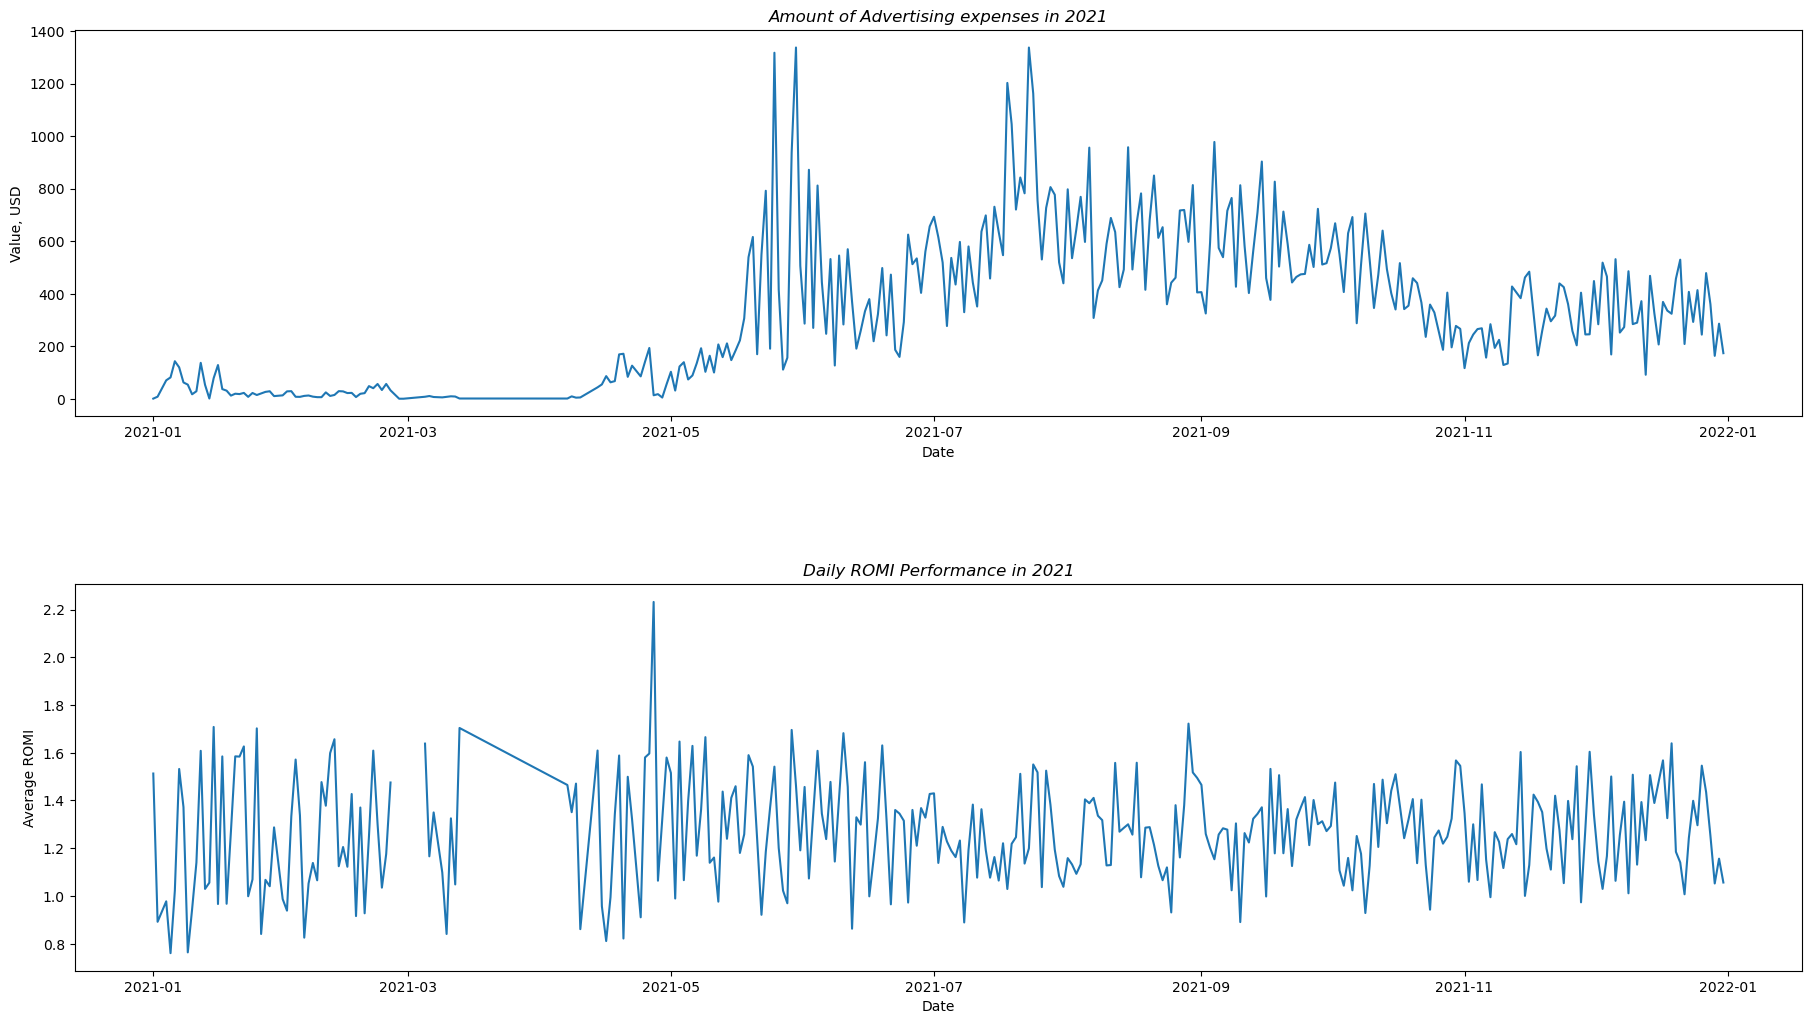

In [28]:
fig, ax = plt.subplots(nrows=2, figsize=(18,10))
fig.tight_layout(h_pad=10, w_pad=10)

ax[0].plot('ad_date', 'total_spend', data = daily_spend)
ax[0].set_xlabel('Date')
ax[0].set_ylabel('Value, USD')
ax[0].set_title('Amount of Advertising expenses in 2021', fontstyle='italic')

ax[1].plot('ad_date', 'my_romi', data = daily_romi)
ax[1].set_xlabel('Date')
ax[1].set_ylabel('Average ROMI')
ax[1].set_title('Daily ROMI Performance in 2021', fontstyle='italic')
plt.show()

A 10-day rolling average

In [29]:
rolling_spend = daily_spend['total_spend'].rolling(window=10, min_periods = 1).mean()
rolling_romi = daily_romi['my_romi'].rolling(window=10, min_periods = 1).mean()

rolling_spend
rolling_romi

0      1.512821
1      1.202147
2      1.127200
3      1.035418
4      1.032817
         ...   
324    1.321545
325    1.314150
326    1.255422
327    1.252572
328    1.244168
Name: my_romi, Length: 329, dtype: float64

Moving average expenses
Moving average ROMI

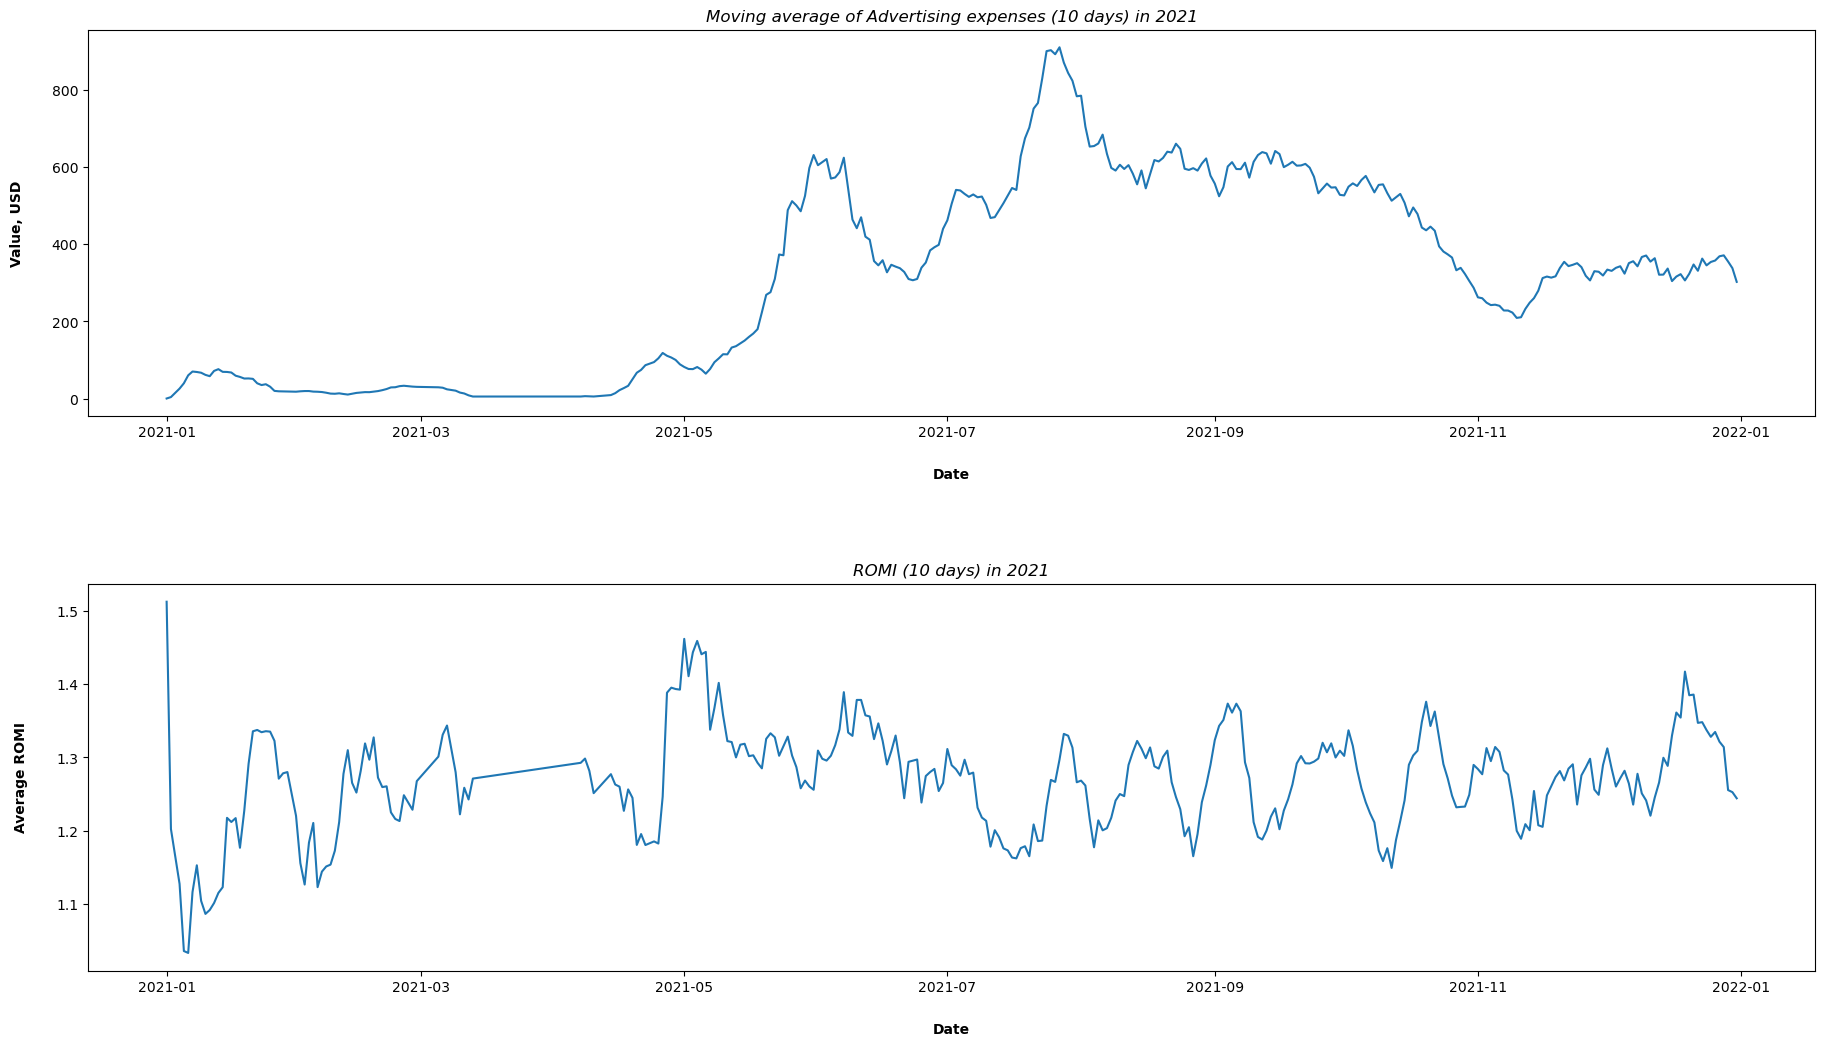

In [30]:
fig, ax = plt.subplots(nrows=2, figsize=(18,10))
fig.tight_layout(h_pad=10, w_pad=10)

ax[0].plot(daily_spend['ad_date'], rolling_spend)
ax[0].set_xlabel('Date', labelpad=20, fontweight='bold')
ax[0].set_ylabel('Value, USD', labelpad=20, fontweight='bold')
ax[0].set_title('Moving average of Advertising expenses (10 days) in 2021', fontstyle='italic')

ax[1].plot(daily_romi['ad_date'], rolling_romi)
ax[1].set_xlabel('Date', labelpad=20, fontweight='bold')
ax[1].set_ylabel('Average ROMI',labelpad=20, fontweight='bold')
ax[1].set_title('ROMI (10 days) in 2021', fontstyle='italic')
plt.show()

Grouping data by campaign name + ROMI

In [31]:
total_cost_for_companies = facebook_ads_data.groupby('campaign_name', as_index=False)['total_spend'].sum().sort_values(by='total_spend',ascending=False)

agg_data_in_companies = facebook_ads_data.groupby('campaign_name', as_index=False)[['total_spend', 'total_value']].sum()
agg_data_in_companies['my_romi'] = agg_data_in_companies['total_value']/agg_data_in_companies['total_spend']
total_romi_in_companies = agg_data_in_companies.loc[:, ['campaign_name', 'my_romi']].sort_values(by='my_romi',ascending=False)

total_romi_in_companies

,campaign_name,my_romi
9,Trendy,1.906782
8,Promos,1.760923
7,New items,1.274119
6,Lookalike,1.260935
0,Brand,1.241202
4,Expansion,1.239178
5,Hobbies,1.233748
2,Discounts,1.231019
10,Wholesale,1.228436
3,Electronics,1.219434


Graph of total advertising spend in each campaign (Matplotlib, Seaborn)
Graph of total ROMI in each campaign (Matplotlib, Seaborn)

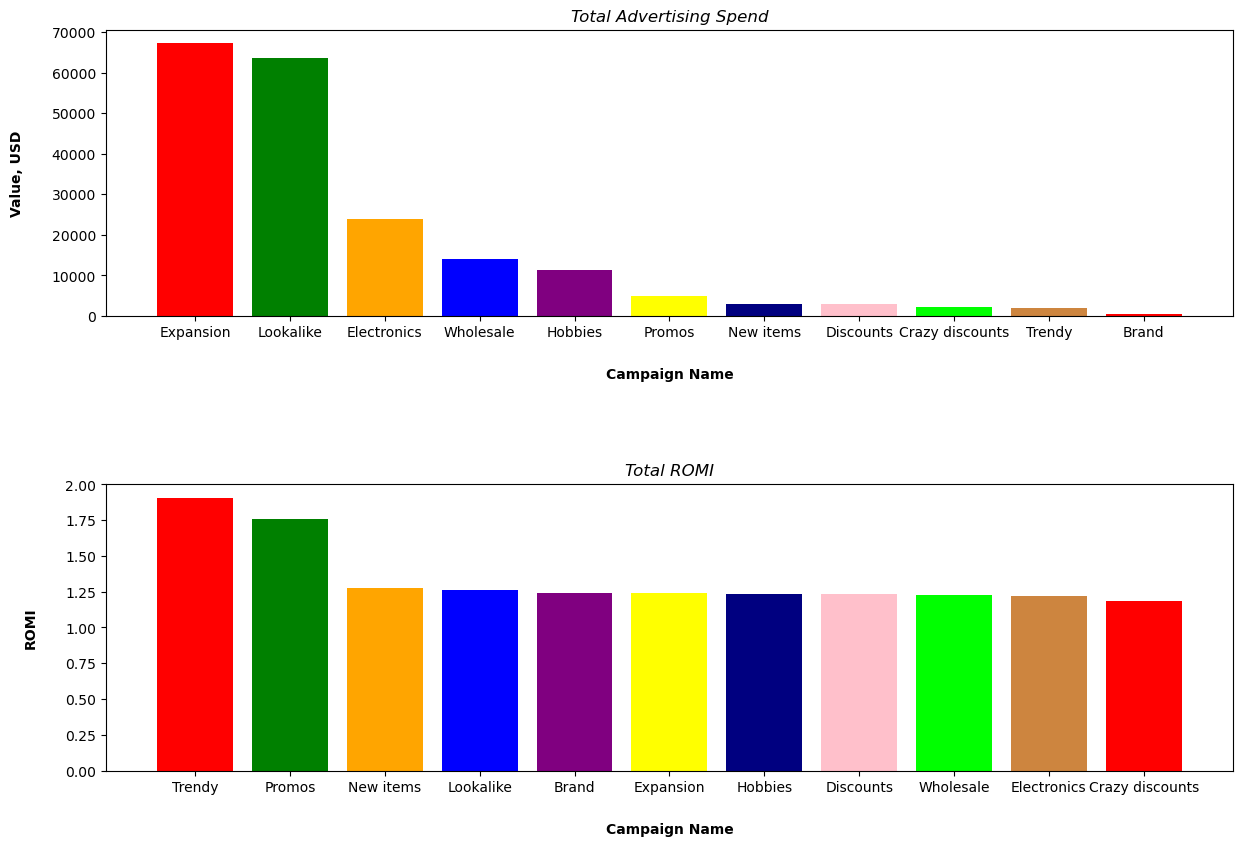

In [32]:
fig, ax = plt.subplots(nrows=2, figsize=(12,8))
fig.tight_layout(h_pad=10, w_pad=10)

ax[0].bar(total_cost_for_companies['campaign_name'],
          total_cost_for_companies['total_spend'],
          color=['red','green','orange','blue','purple','yellow','navy','pink','lime','peru'])
ax[0].set_xlabel('Campaign Name', labelpad=20, fontweight='bold')
ax[0].set_ylabel('Value, USD',labelpad=20, fontweight='bold')
ax[0].set_title('Total Advertising Spend', fontstyle='italic')

ax[1].bar(total_romi_in_companies['campaign_name'],
          total_romi_in_companies['my_romi'],
          color=['red','green','orange','blue','purple','yellow','navy','pink','lime','peru'])
ax[1].set_xlabel('Campaign Name',labelpad=20, fontweight='bold')
ax[1].set_ylabel('ROMI',labelpad=20,fontweight='bold')
ax[1].set_title('Total ROMI', fontstyle='italic')

plt.show()

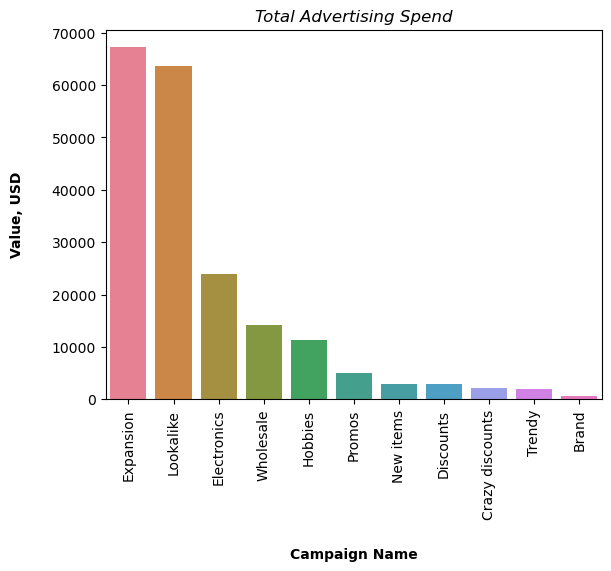

In [33]:
sns.barplot(data=total_cost_for_companies,
            x = 'campaign_name',
            y = 'total_spend',
            hue='campaign_name')
plt.xticks(rotation=90)
plt.ylabel('Value, USD', labelpad=20, fontweight='bold')
plt.xlabel('Campaign Name',labelpad=20, fontweight='bold')
plt.title('Total Advertising Spend', fontstyle='italic')

plt.show()

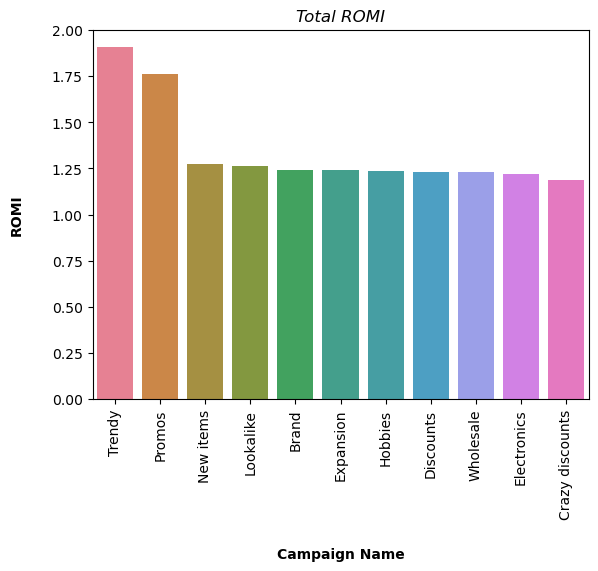

In [34]:
sns.barplot(data=total_romi_in_companies,
            x = 'campaign_name',
            y = 'my_romi',
            hue='campaign_name')
plt.xticks(rotation=90)
plt.ylabel('ROMI', labelpad=20, fontweight='bold')
plt.xlabel('Campaign Name',labelpad=20, fontweight='bold')
plt.title('Total ROMI', fontstyle='italic')

plt.show()

Daily ROMI spread in each campaign

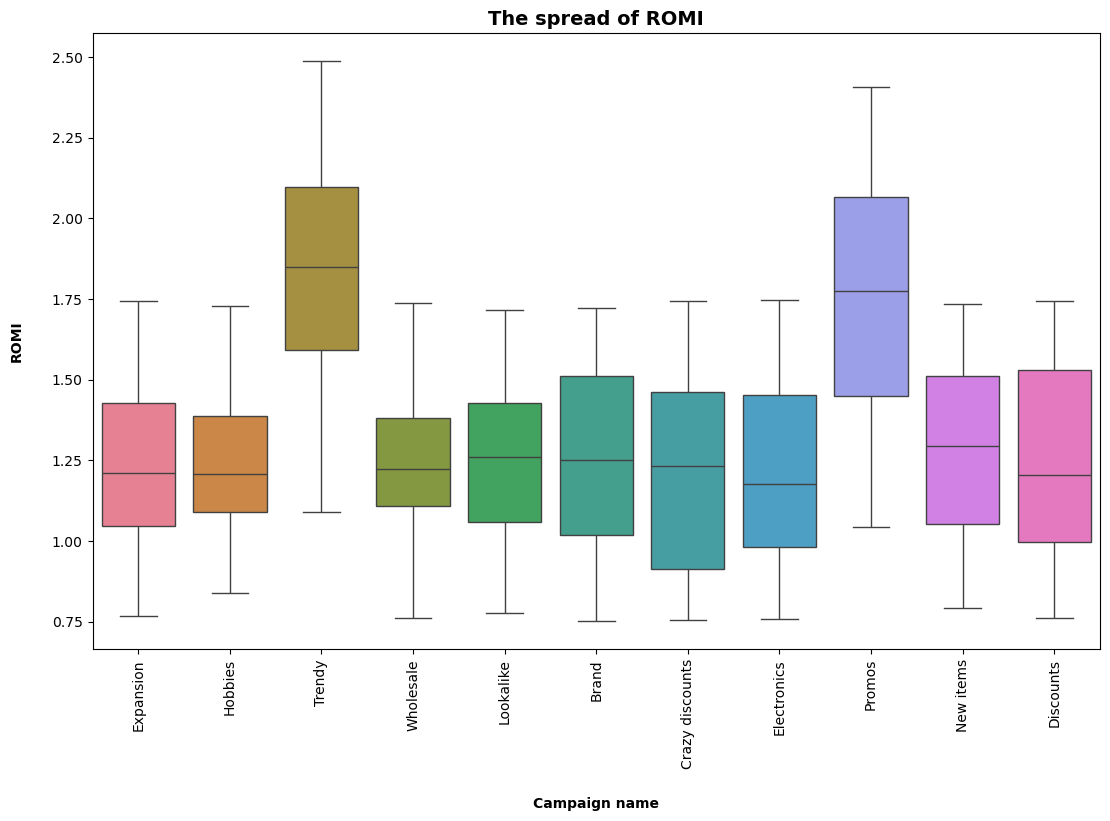

In [35]:
plt.figure(figsize = (13,8))
sns.boxplot(facebook_ads_data, x='campaign_name', y='romi', hue='campaign_name')
plt.xticks(rotation = 90)
plt.xlabel('Campaign name', labelpad = 20, fontweight='bold')
plt.ylabel('ROMI', labelpad = 20, fontweight='bold')
plt.title('The spread of ROMI', fontsize=14, fontweight='bold')

plt.show()

Heatmap of the correlation between all the numeric metrics in the facebook_ads_data.csv table

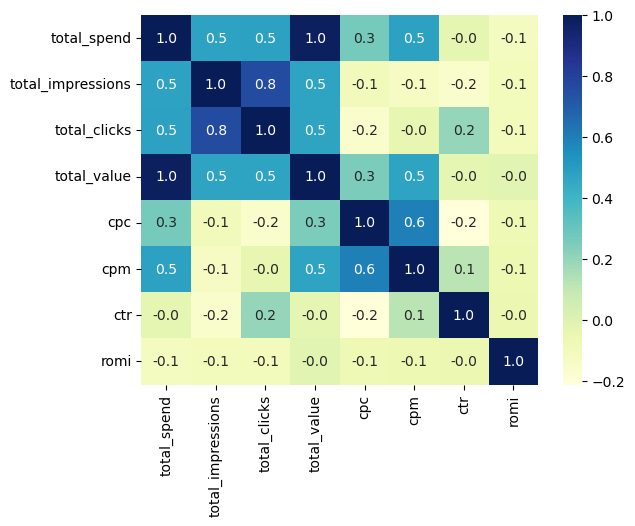

In [36]:
corr_matrix = facebook_ads_data[['total_spend','total_impressions','total_clicks','total_value','cpc','cpm','ctr','romi']].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.1f', cmap='YlGnBu')
plt.show()

The highest positive correlation (1.0) exists between total_spend and total_value. Additionally, total_impressions and total_clicks show a strong correlation (0.8).

The lowest correlation is between ctr and total_spend, ctr and total_value, and ctr and cpc (all at -0.0 or -0.2, indicating almost no linear relationship or a very weak negative one).

total_value correlation: It correlates perfectly (1.0) with total_spend.

A scatter plot with linear regression built on data from "total_spend" and "total_value"

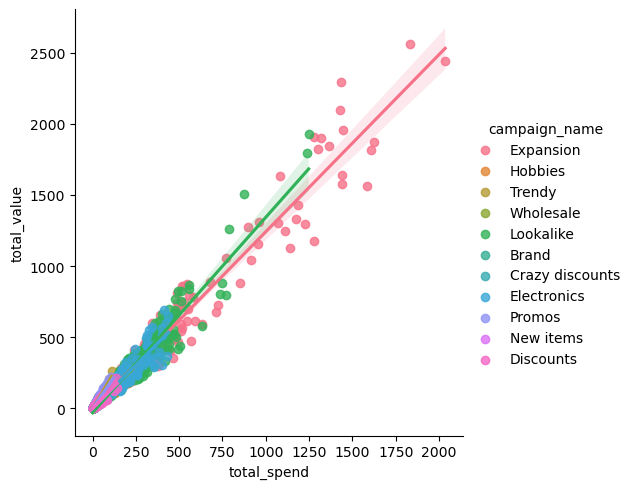

In [37]:
sns.lmplot(facebook_ads_data, x='total_spend', y='total_value', hue='campaign_name')

plt.show()